Project 2: Sleep Health & Daily Performance

Introduction: This project explores sleep health among different occupations. This analysis serves to analyze sleep quality and stress scores over occupations. 

In [45]:
import pandas as pd
df=pd.read_csv("sleep_health_dataset.csv")
df.head(25)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0
5,6,23,Female,Driver,25.5,Brazil,8.16,5.7,17.3,20.1,...,71,1,0,22.7,0.70,Summer,Weekend,49.9,Mild,1
6,7,20,Female,Software Engineer,18.2,Netherlands,7.27,5.1,17.5,18.8,...,79,0,0,17.6,0.73,Spring,Weekend,57.9,Mild,1
7,8,48,Female,Freelancer,31.5,UK,8.04,6.5,25.3,22.3,...,60,1,0,21.6,0.47,Winter,Weekend,92.0,Mild,0
8,9,37,Male,Manager,29.9,USA,6.04,5.4,18.9,15.7,...,74,0,0,17.8,1.80,Autumn,Weekend,53.6,Mild,0
9,10,41,Female,Nurse,34.8,USA,6.22,4.9,21.4,15.5,...,80,1,0,24.4,1.51,Autumn,Weekday,67.8,Mild,1


Data Overview: This dataset consists of 100,000 patient records collected from peer-reviewed sources on sleep quality, stress, and daily performance.

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [47]:
df.columns

Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested'],
      dtype='object')

In [48]:
df.shape

(100000, 32)

Data Cleaning: Used df.isnull().sum(), but did not find problems in the quality nor duplicates in the data.

In [65]:
df.isnull().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

In [66]:
df.duplicated().sum()

np.int64(0)

Exploration Analysis: 

In [49]:
df['age'].describe()

count    100000.000000
mean         34.706870
std          11.036373
min          18.000000
25%          26.000000
50%          33.000000
75%          42.000000
max          69.000000
Name: age, dtype: float64

In [50]:
df['gender'].value_counts()

gender
Female    50203
Male      47823
Other      1974
Name: count, dtype: int64

In [51]:
df['occupation'].unique()

array(['Driver', 'Software Engineer', 'Nurse', 'Student', 'Lawyer',
       'Freelancer', 'Manager', 'Doctor', 'Homemaker', 'Teacher',
       'Retired', 'Sales'], dtype=object)

In [52]:
df['occupation'].value_counts()

occupation
Student              14851
Software Engineer    12068
Nurse                10073
Manager               8101
Teacher               8047
Doctor                7868
Retired               7036
Sales                 7017
Freelancer            7016
Driver                6996
Homemaker             5923
Lawyer                5004
Name: count, dtype: int64

In [53]:
df['sleep_duration_hrs'].describe()

count    100000.000000
mean          6.423986
std           1.274627
min           3.000000
25%           5.530000
50%           6.360000
75%           7.270000
max          10.500000
Name: sleep_duration_hrs, dtype: float64

In [54]:
df['sleep_quality_score'].describe()

count    100000.000000
mean          4.871144
std           1.506517
min           1.000000
25%           3.800000
50%           4.900000
75%           6.000000
max          10.000000
Name: sleep_quality_score, dtype: float64

In [55]:
df.groupby("occupation")['sleep_quality_score'].describe()

,count,mean,std,min,25%,50%,75%,max
occupation,,,,,,,,
Doctor,7868.0,4.255084,1.356511,1.0,3.3,4.2,5.200,8.5
Driver,6996.0,4.303073,1.378260,1.0,3.4,4.3,5.225,8.6
Freelancer,7016.0,5.652751,1.272211,1.0,4.9,5.8,6.600,9.4
Homemaker,5923.0,5.678372,1.279003,1.0,4.9,5.8,6.600,9.0
Lawyer,5004.0,4.004616,1.344827,1.0,3.1,3.9,4.900,8.4
Manager,8101.0,4.677077,1.373001,1.0,3.7,4.7,5.600,9.1
Nurse,10073.0,4.111317,1.389693,1.0,3.1,4.1,5.100,8.9
Retired,7036.0,6.620679,1.118008,1.7,5.9,6.7,7.400,10.0
Sales,7017.0,4.892333,1.365460,1.0,4.0,5.0,5.900,9.3


In [56]:
df.groupby("occupation")['deep_sleep_percentage'].describe()

,count,mean,std,min,25%,50%,75%,max
occupation,,,,,,,,
Doctor,7868.0,19.857486,4.278541,5.0,17.0,19.8,22.8,30.0
Driver,6996.0,20.125086,4.247557,5.0,17.2,20.2,23.1,30.0
Freelancer,7016.0,20.508181,4.243243,5.0,17.6,20.6,23.5,30.0
Homemaker,5923.0,20.541601,4.177174,5.0,17.6,20.6,23.4,30.0
Lawyer,5004.0,19.752278,4.336900,5.0,16.9,19.8,22.8,30.0
Manager,8101.0,20.373398,4.282104,5.2,17.5,20.4,23.3,30.0
Nurse,10073.0,19.810642,4.272803,5.0,16.9,19.8,22.7,30.0
Retired,7036.0,20.558215,4.205031,6.0,17.8,20.6,23.5,30.0
Sales,7017.0,20.328303,4.187921,5.0,17.5,20.4,23.2,30.0


In [57]:
df['caffeine_mg_before_bed'].unique()

array([  0,  40, 150, 400,  80, 300, 200, 100])

In [58]:
df['caffeine_mg_before_bed'].value_counts()

caffeine_mg_before_bed
0      65010
80      8850
40      8690
100     7130
150     5107
200     2805
300     1739
400      669
Name: count, dtype: int64

In [59]:
df['alcohol_units_before_bed'].value_counts()

alcohol_units_before_bed
0.0    68923
1.0    13456
2.0    10049
3.0     5047
4.0     1819
5.0      527
6.0      179
Name: count, dtype: int64

In [60]:
df['stress_score'].describe()

count    100000.000000
mean          5.733285
std           1.619194
min           1.000000
25%           4.800000
50%           5.800000
75%           6.800000
max          10.000000
Name: stress_score, dtype: float64

In [61]:
df.groupby("occupation")['stress_score'].describe()

,count,mean,std,min,25%,50%,75%,max
occupation,,,,,,,,
Doctor,7868.0,6.861718,1.173081,2.2,6.10,6.9,7.600,10.0
Driver,6996.0,6.305403,1.189786,1.5,5.50,6.3,7.100,10.0
Freelancer,7016.0,5.037728,1.191397,1.0,4.20,5.0,5.825,9.1
Homemaker,5923.0,4.837245,1.191455,1.0,4.00,4.8,5.700,9.5
Lawyer,5004.0,7.271922,1.158112,3.3,6.50,7.3,8.000,10.0
Manager,8101.0,5.939415,1.183037,1.1,5.10,5.9,6.700,10.0
Nurse,10073.0,7.095463,1.192794,2.2,6.30,7.1,7.900,10.0
Retired,7036.0,2.601180,1.109186,1.0,1.70,2.5,3.400,7.1
Sales,7017.0,5.560254,1.189313,1.4,4.80,5.6,6.400,10.0


In [62]:
df['work_hours_that_day'].describe()

count    100000.000000
mean          7.134059
std           3.482878
min           0.000000
25%           4.700000
50%           7.400000
75%           9.700000
max          18.000000
Name: work_hours_that_day, dtype: float64

In [63]:
df.groupby("occupation")['work_hours_that_day'].mean()

occupation
Doctor               10.610765
Driver                8.152158
Freelancer            6.134151
Homemaker             4.206146
Lawyer               11.621363
Manager               8.621368
Nurse                 9.654671
Retired               1.260262
Sales                 8.089297
Software Engineer     8.153762
Student               4.202478
Teacher               6.617472
Name: work_hours_that_day, dtype: float64

In [64]:
df['wake_episodes_per_night'].value_counts()

wake_episodes_per_night
3    20509
2    19330
4    16976
1    12875
5    11716
6     7024
0     4467
7     3853
8     3250
Name: count, dtype: int64

SQL Analysis: This analysis explores the difference in sleep quality and stress among the different occupations.

In [67]:
import sqlite3
conn = sqlite3.connect("sleep.db")

In [68]:
df.to_sql("sleep_data", conn, if_exists = "replace", index=False)

100000

Question 1: How do sleep duration, sleep quality, and stress differ across occupations?

In [69]:
query = """
SELECT occupation, AVG("sleep_duration_hrs") as avg_sleep, AVG("sleep_quality_score") as avg_sleep_quality, AVG("stress_score") as avg_stress
FROM sleep_data
GROUP BY occupation
ORDER BY avg_sleep DESC;
"""

result=pd.read_sql_query(query,conn)
result

,occupation,avg_sleep,avg_sleep_quality,avg_stress
0,Retired,8.034454,6.620679,2.601180
1,Freelancer,7.335238,5.652751,5.037728
2,Homemaker,7.205664,5.678372,4.837245
3,Teacher,6.869544,5.137629,5.850976
4,Software Engineer,6.443267,5.028455,5.280950
5,Sales,6.310150,4.892333,5.560254
6,Manager,6.140412,4.677077,5.939415
7,Student,6.011794,4.576022,5.866554
8,Doctor,5.929628,4.255084,6.861718
9,Nurse,5.908215,4.111317,7.095463


<Axes: title={'center': 'Average Sleep Duration and Sleep Quality Among Occupations'}, xlabel='occupation'>

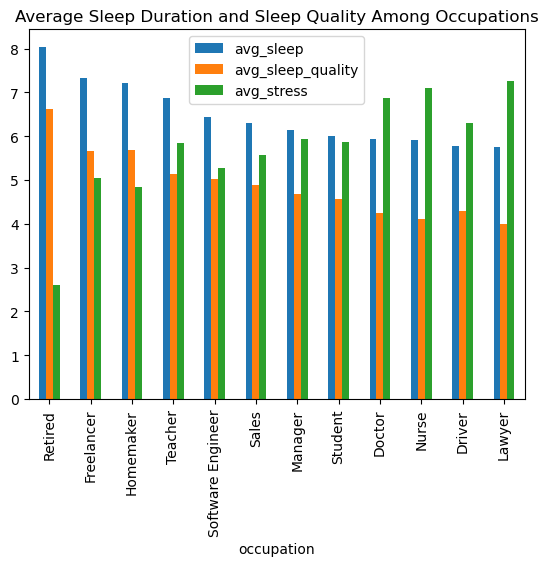

In [70]:
result.plot(
title = "Average Sleep Duration and Sleep Quality Among Occupations",
x = "occupation",
y = ["avg_sleep", "avg_sleep_quality", "avg_stress"],
kind = 'bar')

Sleep duration, sleep quality, and stress varied considerably across occupations. Lawyers, drivers, nurses, doctors, and students were among the five occupations with the lowest average sleep duration and sleep quality. Retired individuals reported an average sleep quality of approximately 6.62 and an average stress score of 2.60. In comparison, occupations such as Freelancers (avg_sleep_quality = 5.65, avg_stress = 5.04), Homemakers (avg_sleep_quality = 5.68, avg_stress = 4.84), and Teachers (avg_sleep_quality = 5.14, avg_stress = 5.85) reported lower average sleep quality and higher average stress scores. These differences suggest that sleep quality and stress may vary according to lifestyle factors associated with different occupations.

Question 2: How do work hours vary across occupations and how are they related to stress?

In [71]:
query = """
SELECT "occupation", AVG("work_hours_that_day") as avg_work_hrs, AVG("stress_score") as avg_stress
FROM sleep_data
GROUP BY occupation
ORDER BY avg_stress DESC;
"""

result=pd.read_sql_query(query,conn)
result

,occupation,avg_work_hrs,avg_stress
0,Lawyer,11.621363,7.271922
1,Nurse,9.654671,7.095463
2,Doctor,10.610765,6.861718
3,Driver,8.152158,6.305403
4,Manager,8.621368,5.939415
5,Student,4.202478,5.866554
6,Teacher,6.617472,5.850976
7,Sales,8.089297,5.560254
8,Software Engineer,8.153762,5.280950
9,Freelancer,6.134151,5.037728


<Axes: title={'center': 'Average Stress and Work Hours Among Occupations'}, xlabel='occupation'>

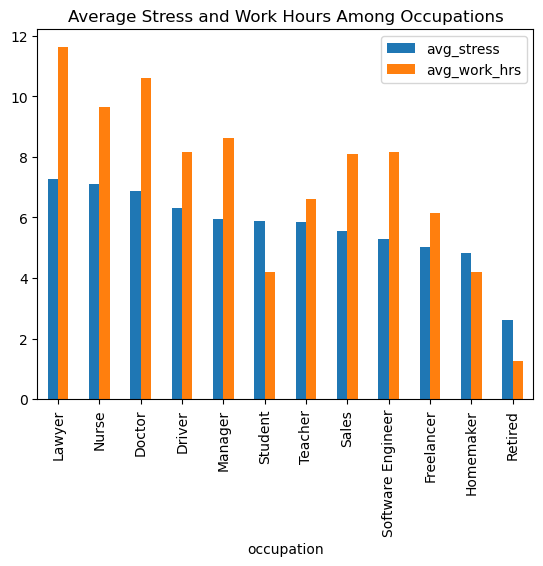

In [72]:
result.plot(
title = "Average Stress and Work Hours Among Occupations",
x = "occupation",
y = [ "avg_stress", "avg_work_hrs",],
kind = 'bar')

Average work hours (min = 1.26, max = 11.62) varied more widely across occupations than average stress scores (min = 2.60, max = 7.27). Lawyers reported the highest average work hours (M = 11.62) and the highest average stress score (M = 7.27). Nurses (avg_work_hours = 9.65) and doctors (avg_work_hours = 10.61) reported fewer average work hours than lawyers; however, their average stress scores were only slightly lower (M = 7.10 and M = 6.86, respectively). These findings suggest that stress levels may also be associated with occupation-specific factors, such as the nature and demands of the work.

Question 3: What is the relationship between sleep quality and stress?

In [86]:
df["work_hours_that_day"].corr(df["stress_score"])

np.float64(0.49251024870062227)

In [73]:
df["work_hours_that_day"].corr(df["stress_score"])

np.float64(0.49251024870062227)

In [74]:
df["deep_sleep_percentage"].corr(df["sleep_quality_score"])

np.float64(0.09063063256682934)

In [75]:
df["wake_episodes_per_night"].corr(df["sleep_quality_score"])

np.float64(-0.3812302751037351)

In [76]:
df["caffeine_mg_before_bed"].corr(df["sleep_quality_score"])

np.float64(-0.05037277055533449)

In [77]:
df["shift_work"].corr(df["sleep_quality_score"])

np.float64(-0.2634068997759987)

In [78]:
df["sleep_quality_score"].corr(df["stress_score"])

np.float64(-0.6388278090726226)

In [79]:
query = """
SELECT "occupation", AVG("sleep_quality_score") as avg_sleep_quality, AVG("stress_score") as avg_stress
FROM sleep_data
GROUP BY "occupation"
ORDER BY avg_stress DESC;
"""

result=pd.read_sql_query(query,conn)
result

,occupation,avg_sleep_quality,avg_stress
0,Lawyer,4.004616,7.271922
1,Nurse,4.111317,7.095463
2,Doctor,4.255084,6.861718
3,Driver,4.303073,6.305403
4,Manager,4.677077,5.939415
5,Student,4.576022,5.866554
6,Teacher,5.137629,5.850976
7,Sales,4.892333,5.560254
8,Software Engineer,5.028455,5.280950
9,Freelancer,5.652751,5.037728


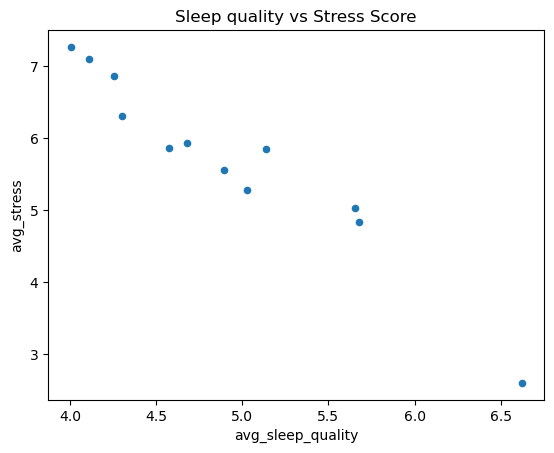

In [80]:
import matplotlib.pyplot as plt
result.plot.scatter(
    x = "avg_sleep_quality",
    y = "avg_stress")

plt.xlabel("avg_sleep_quality")
plt.ylabel("avg_stress")
plt.title("Sleep quality vs Stress Score")

plt.show()

Across occupations as a whole, higher sleep quality was associated with lower stress. The correlation between the two variables was r = -0.64, indicating a moderate negative relationship between average sleep quality and average stress. This relationship was stronger than the correlation between work hours and stress scores (r = 0.49), suggesting that sleep quality may be more closely associated with stress levels within this dataset. However, this analysis identifies an association rather than a causal relationship, and other factors such as work hours, sleep duration, or occupation-specific characteristics may also contribute to differences in stress levels.

Question 4: How do wake episodes relate to sleep quality and stress among lawyers?

In [82]:
df.groupby("occupation")['stress_score'].describe()

,count,mean,std,min,25%,50%,75%,max
occupation,,,,,,,,
Doctor,7868.0,6.861718,1.173081,2.2,6.10,6.9,7.600,10.0
Driver,6996.0,6.305403,1.189786,1.5,5.50,6.3,7.100,10.0
Freelancer,7016.0,5.037728,1.191397,1.0,4.20,5.0,5.825,9.1
Homemaker,5923.0,4.837245,1.191455,1.0,4.00,4.8,5.700,9.5
Lawyer,5004.0,7.271922,1.158112,3.3,6.50,7.3,8.000,10.0
Manager,8101.0,5.939415,1.183037,1.1,5.10,5.9,6.700,10.0
Nurse,10073.0,7.095463,1.192794,2.2,6.30,7.1,7.900,10.0
Retired,7036.0,2.601180,1.109186,1.0,1.70,2.5,3.400,7.1
Sales,7017.0,5.560254,1.189313,1.4,4.80,5.6,6.400,10.0


In [81]:
query = """
SELECT "occupation", "wake_episodes_per_night" as wake_episodes, AVG("sleep_quality_score") as avg_sleep_quality, AVG("stress_score") as avg_stress
FROM sleep_data
WHERE "occupation" = 'Lawyer'
GROUP BY "wake_episodes_per_night"
ORDER BY "wake_episodes_per_night";
"""

result=pd.read_sql_query(query,conn)
result

,occupation,wake_episodes,avg_sleep_quality,avg_stress
0,Lawyer,0,4.850694,7.091667
1,Lawyer,1,4.749293,7.079596
2,Lawyer,2,4.462680,7.161019
3,Lawyer,3,4.152204,7.221944
4,Lawyer,4,3.890562,7.350899
5,Lawyer,5,3.693506,7.287446
6,Lawyer,6,3.390097,7.417633
7,Lawyer,7,3.146122,7.505714
8,Lawyer,8,2.790541,7.598649


<Axes: title={'center': 'Average Sleep Quality and Stress Score Based on Wake Episodes in Lawyers'}, xlabel='wake_episodes'>

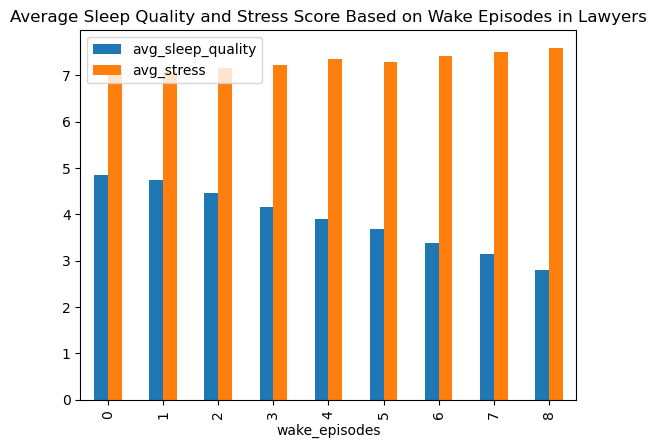

In [83]:
result.plot(
title = "Average Sleep Quality and Stress Score Based on Wake Episodes in Lawyers",
x = "wake_episodes",
y = [ "avg_sleep_quality", "avg_stress"],
kind = 'bar')

As wake episodes increased, average sleep quality declined while average stress slightly increased among lawyers. Average sleep quality decreased from 4.85 (at 0 wake episodes) to 2.79 (at 8 wake episodes), while average stress increased from 7.09 (at 0 wake episodes) to 7.60 (at 8 wake episodes). Wake episode groups ranging from 0–3 reported stress scores (7.09–7.22) below the overall average stress score for lawyers (7.27) and sleep quality scores (4.15–4.85) above the overall average sleep quality score (4.00). These findings suggest that wake episodes may negatively impact sleep quality; however, wake episodes and their effect on sleep quality do not fully explain differences in stress levels among lawyers.

Findings:

* The top 5 occupations with the lowest sleep quality are: Lawyers, Drivers, Nurses, Doctors, and Students.
* The top 5 occupations with the highest average stress are: Lawyers, Nurses, Doctors, Drivers, and Managers.
* Sleep quality and stress showed a moderate negative correlation (r = -0.64) compared to the slightly lower, postivie correlation between work hours and stress scores (r = 0.49).
* Increase in wake episodes were associated with slightly higher average stress.

Conclusion: Across occupations, average sleep quality, stress scores, and work hours varied considerably. Occupations with higher average sleep quality generally reported lower average stress scores, with a moderate negative correlation observed between sleep quality and stress (r = -0.64). Analysis of wake episodes among lawyers showed that increased wake episodes were associated with lower sleep quality and slightly higher stress levels. Overall, the results suggest that sleep quality may be more closely associated with stress than work hours alone within this dataset. However, these findings represent associations rather than causal relationships, and other occupation-specific or individual factors may also contribute to differences in stress levels.